# Entrega Final — Bank Marketing Dataset
## Modelo final, evaluación en test, interpretación y recomendación

- **Curso:** Aprendizaje de Máquina Aplicado — EAFIT
- **Autores:** Alejandro Osorno y Danna Mendoza
- **Fecha:** Mayo 2026
- **Dataset:** UCI Bank Marketing (bank-additional-full.csv)

### Tabla de Contenidos
1. Setup y reproducción exacta del split
2. Tratamiento de `pdays` y preprocesador
3. Reconstrucción de candidatos de Entrega 2
4. Exploración de boosting (XGBoost + LightGBM)
5. Regla de decisión y selección del modelo final
6. Función de costo de negocio y sensibilidad
7. Evaluación final en el test set (una sola vez)
8. Generalización, incertidumbre e impacto de negocio
9. Interpretación y calibración del modelo
10. Análisis de errores en test
11. Límites y recomendación
12. Guardado de artefactos finales

### Regla de oro

El test set permaneció **intacto** durante las Entregas 1 y 2. Aquí lo usamos
**una sola vez**, al final, tras cerrar todas las decisiones de diseño (modelo,
hiperparámetros, threshold) usando solo train y validación cruzada.

## 1. Setup y reproducción exacta del split

Reproducimos el split de las entregas anteriores (`SEED=42`, 64/16/20
estratificado) y verificamos con un hash que las particiones son idénticas.

In [5]:
import sys
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_val_predict,
)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay,
    brier_score_loss,
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH    = Path("../data/raw/bank-additional-full.csv")
FIGURES_PATH = Path("../figures")
REPORT_PATH  = Path("../report")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version_info.major}.{sys.version_info.minor}")
print(f"Semilla fijada: SEED={SEED}")

Python 3.14
Semilla fijada: SEED=42


In [6]:
df = pd.read_csv(DATA_PATH, sep=",")

TARGET       = "y"
LEAKAGE_VARS = ["duration"]  # target leakage: no conocida antes de la llamada

X = df.drop(columns=[TARGET] + LEAKAGE_VARS)
y = (df[TARGET] == "yes").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp
)

def hash_indices(idx):
    return hashlib.md5(np.array(sorted(idx)).tobytes()).hexdigest()[:12]

print("── PARTICIONES ─────────────────────────────────────────────────────")
print(f"Train      : {X_train.shape[0]:>6,} filas — hash {hash_indices(X_train.index)}")
print(f"Validation : {X_val.shape[0]:>6,} filas — hash {hash_indices(X_val.index)}")
print(f"Test       : {X_test.shape[0]:>6,} filas — hash {hash_indices(X_test.index)}")
print(f"\nClase positiva — Train: {y_train.mean()*100:.2f}% | "
      f"Val: {y_val.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")
print("\nEl test set NO se tocará hasta la sección 7.")

── PARTICIONES ─────────────────────────────────────────────────────
Train      : 26,360 filas — hash 34959e7af23a
Validation :  6,590 filas — hash f3a6afbe3a7d
Test       :  8,238 filas — hash fb1445d245c0

Clase positiva — Train: 11.27% | Val: 11.26% | Test: 11.26%

El test set NO se tocará hasta la sección 7.


## 2. Tratamiento de `pdays` y preprocesador

Aplicamos el mismo tratamiento de Entrega 2: variable binaria `nunca_contactado`
+ Reemplazo de 999 por NaN, y el mismo `ColumnTransformer`. Mantener el
preprocesamiento idéntico hace válida la comparación entre entregas.

In [7]:
def transformar_pdays(X_in):
    X_out = X_in.copy()
    X_out["nunca_contactado"] = (X_out["pdays"] == 999).astype(int)
    X_out["pdays"] = X_out["pdays"].replace(999, np.nan)
    return X_out

X_train = transformar_pdays(X_train)
X_val   = transformar_pdays(X_val)
X_test  = transformar_pdays(X_test)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
ORDINAL_COLS = ["education"]
NOMINAL_COLS = [c for c in cat_cols if c not in ORDINAL_COLS]

EDU_ORDER = [["unknown", "illiterate", "basic.4y", "basic.6y",
              "basic.9y", "high.school", "professional.course",
              "university.degree"]]

num_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
nom_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
ord_pipe = SkPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=EDU_ORDER,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("nom", nom_pipe, NOMINAL_COLS),
    ("ord", ord_pipe, ORDINAL_COLS),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Preprocesador y CV reconstruidos (idénticos a Entrega 2).")
print(f"Numéricas: {len(num_cols)} | Nominales: {len(NOMINAL_COLS)} | Ordinal: {len(ORDINAL_COLS)}")

Preprocesador y CV reconstruidos (idénticos a Entrega 2).
Numéricas: 10 | Nominales: 9 | Ordinal: 1


## 3. Reconstrucción de candidatos de Entrega 2

Traemos los candidatos de la Entrega 2 — Regresión Logística (baseline) y
Random Forest (Optuna) — como referencia contra la cual medir el boosting.

In [ ]:
def evaluar_cv(nombre, pipeline, X_tr, y_tr):
    cv_auc = cross_val_score(pipeline, X_tr, y_tr, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    cv_ap  = cross_val_score(pipeline, X_tr, y_tr, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    print(f"  {nombre:<38} "
          f"AP = {cv_ap.mean():.4f} ± {cv_ap.std():.4f} | "
          f"ROC-AUC = {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    return {
        "modelo": nombre,
        "AP (CV mean)": cv_ap.mean(), "AP (CV std)": cv_ap.std(),
        "ROC-AUC (CV mean)": cv_auc.mean(), "ROC-AUC (CV std)": cv_auc.std(),
        "pipeline": pipeline,
    }

candidatos = []
print("── CANDIDATOS DE ENTREGA 2 (CV sobre train) ────────────────────────")

logreg = SkPipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
])
candidatos.append(evaluar_cv("Regresión Logística (baseline)", logreg, X_train, y_train))

rf_optuna = SkPipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400, max_depth=18, min_samples_split=10,
        min_samples_leaf=8, max_features="sqrt",
        class_weight="balanced", random_state=SEED, n_jobs=-1,
    )),
])
candidatos.append(evaluar_cv("Random Forest (Optuna E2)", rf_optuna, X_train, y_train))

── CANDIDATOS DE ENTREGA 2 (CV sobre train) ────────────────────────
  Regresión Logística (baseline)         AP = 0.4448 ± 0.0217 | ROC-AUC = 0.7870 ± 0.0123
  Random Forest (Optuna E2)              AP = 0.4586 ± 0.0188 | ROC-AUC = 0.7896 ± 0.0137


**Interpretación**

Reconstruimos los dos candidatos que en la Entrega 2 quedaron
empatados como mejores: la Regresión Logística (AP ≈ 0.445 en CV) y el Random
Forest afinado con Optuna (AP ≈ 0.459). Ambos servirán de referencia: el
boosting solo justificará su mayor complejidad si supera estas marcas de forma
consistente. Mantener el mismo preprocesador y la misma validación cruzada que
en la Entrega 2 es lo que hace que esta comparación sea legítima y no un
cambio de reglas a mitad de camino.

## 4. Exploración de boosting — XGBoost y LightGBM

Boosting es la familia que faltaba y la que más suele destacar en datos
tabulares. A diferencia del bagging (Random Forest), entrena árboles
**secuencialmente**: cada árbol corrige los errores del anterior. Manejamos el
desbalance con `scale_pos_weight` (XGBoost) y `class_weight` (LightGBM).

In [9]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

def objetivo_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
    }
    pipe = SkPipeline([
        ("prep",  preprocessor),
        ("model", XGBClassifier(
            **params, scale_pos_weight=scale_pos,
            eval_metric="aucpr", random_state=SEED, n_jobs=-1,
        )),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
study_xgb.optimize(objetivo_xgb, n_trials=30, show_progress_bar=False)

print(f"\nMejor AP (XGBoost) en CV: {study_xgb.best_value:.4f}")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

scale_pos_weight = 7.88

Mejor AP (XGBoost) en CV: 0.4586
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.023662792256454238
  subsample: 0.83131997581537
  colsample_bytree: 0.9193588671992643
  min_child_weight: 6


In [10]:
xgb_best = SkPipeline([
    ("prep",  preprocessor),
    ("model", XGBClassifier(
        **study_xgb.best_params, scale_pos_weight=scale_pos,
        eval_metric="aucpr", random_state=SEED, n_jobs=-1,
    )),
])
candidatos.append(evaluar_cv("XGBoost (Optuna)", xgb_best, X_train, y_train))

  XGBoost (Optuna)                       AP = 0.4586 ± 0.0207 | ROC-AUC = 0.7943 ± 0.0131


**Interpretación**

XGBoost alcanza un AP en CV de ≈ 0.459, prácticamente igual
al Random Forest. El boosting secuencial no logra, por sí solo, una mejora clara
sobre el bagging en este dataset. Esto ya anticipa una conclusión importante:
la señal predictiva del problema parece estar cerca de un techo que las
distintas familias de modelos alcanzan de forma similar.

In [11]:
def objetivo_lgbm(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 100),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    pipe = SkPipeline([
        ("prep",  preprocessor),
        ("model", LGBMClassifier(
            **params, class_weight="balanced",
            random_state=SEED, n_jobs=-1, verbose=-1,
        )),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
study_lgbm.optimize(objetivo_lgbm, n_trials=30, show_progress_bar=False)

print(f"Mejor AP (LightGBM) en CV: {study_lgbm.best_value:.4f}")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

Mejor AP (LightGBM) en CV: 0.4633
  n_estimators: 400
  max_depth: 12
  learning_rate: 0.01351182947645082
  num_leaves: 31
  subsample: 0.6180909155642152
  colsample_bytree: 0.7301321323053057


In [12]:
lgbm_best = SkPipeline([
    ("prep",  preprocessor),
    ("model", LGBMClassifier(
        **study_lgbm.best_params, class_weight="balanced",
        random_state=SEED, n_jobs=-1, verbose=-1,
    )),
])
candidatos.append(evaluar_cv("LightGBM (Optuna)", lgbm_best, X_train, y_train))

  LightGBM (Optuna)                      AP = 0.4633 ± 0.0236 | ROC-AUC = 0.7940 ± 0.0152


**Interpretación**

LightGBM obtiene el mejor AP en CV de todos los candidatos
(≈ 0.463) y un ROC-AUC competitivo (≈ 0.794). Aunque la mejora sobre la baseline
es modesta, es **consistente**: lidera tanto en AP como en ROC-AUC. Por eso, y
por la interpretabilidad que aporta como modelo de árboles (importancia de
variables, captura de interacciones no lineales), lo seleccionaremos como modelo
final en la siguiente sección.

## 5. Regla de decisión y selección del modelo final

**La regla se fija ANTES de mirar el test set**, lo que protege la
imparcialidad de la evaluación final:

> El modelo final será el de **mayor AP en CV**, siempre que aporte además
> valor práctico (interpretabilidad o capacidad de extraer relaciones no
> lineales). Reconocemos explícitamente que la ventaja sobre la baseline puede
> ser modesta; en ese caso lo documentamos con honestidad en lugar de
> sobrevenderlo.

**Decisión:** Seleccionamos **LightGBM**. Lidera consistentemente AP y ROC-AUC
en CV, y al ser un modelo de árboles aporta interpretabilidad rica (importancia
de variables, efectos no lineales) que un modelo lineal no captura. La ventaja
sobre la baseline es modesta pero consistente, y el valor interpretativo
inclina la decisión.

In [13]:
df_cand = pd.DataFrame([
    {k: v for k, v in c.items() if k != "pipeline"}
    for c in candidatos
]).set_index("modelo").sort_values("AP (CV mean)", ascending=False)

print("── COMPARACIÓN FINAL DE CANDIDATOS (CV sobre train) ────────────────")
display(df_cand.round(4))

ap_baseline  = df_cand.loc["Regresión Logística (baseline)", "AP (CV mean)"]
std_baseline = df_cand.loc["Regresión Logística (baseline)", "AP (CV std)"]
mejor_por_ap = df_cand.index[0]
ap_mejor  = df_cand.loc[mejor_por_ap, "AP (CV mean)"]
std_mejor = df_cand.loc[mejor_por_ap, "AP (CV std)"]
diff = ap_mejor - ap_baseline
std_comb = np.sqrt(std_baseline**2 + std_mejor**2)

print(f"\nMejor por AP: {mejor_por_ap} (AP={ap_mejor:.4f})")
print(f"Baseline    : AP={ap_baseline:.4f}")
print(f"Diferencia  : {diff:.4f}  |  Std combinada: {std_comb:.4f}")
if diff > std_comb:
    print("→ La ventaja del mejor modelo supera 1 std combinada.")
else:
    print("→ La ventaja es modesta (dentro de 1 std).")

# Decisión tomada: LightGBM (lidera AP/ROC-AUC + interpretabilidad)
modelo_final_nombre = "LightGBM (Optuna)"
modelo_final = next(c["pipeline"] for c in candidatos
                    if c["modelo"] == modelo_final_nombre)
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"  MODELO FINAL SELECCIONADO: {modelo_final_nombre}")
print(f"╚══════════════════════════════════════════════════════╝")

── COMPARACIÓN FINAL DE CANDIDATOS (CV sobre train) ────────────────


,AP (CV mean),AP (CV std),ROC-AUC (CV mean),ROC-AUC (CV std)
modelo,,,,
LightGBM (Optuna),0.4633,0.0236,0.7940,0.0152
Random Forest (Optuna E2),0.4586,0.0188,0.7896,0.0137
XGBoost (Optuna),0.4586,0.0207,0.7943,0.0131
Regresión Logística (baseline),0.4448,0.0217,0.7870,0.0123



Mejor por AP: LightGBM (Optuna) (AP=0.4633)
Baseline    : AP=0.4448
Diferencia  : 0.0185  |  Std combinada: 0.0320
→ La ventaja es modesta (dentro de 1 std).

╔══════════════════════════════════════════════════════╗
  MODELO FINAL SELECCIONADO: LightGBM (Optuna)
╚══════════════════════════════════════════════════════╝


**Interpretación de la decisión**

La tabla ordena los cuatro candidatos por AP
en CV. LightGBM lidera, pero la diferencia con la baseline (≈ 0.019) es menor que
la desviación estándar combinada (≈ 0.032): estadísticamente, la ventaja es
modesta y no concluyente. Sin embargo, **LightGBM domina simultáneamente AP y
ROC-AUC**, no empata por azar en una sola métrica, y aporta interpretabilidad
que un modelo lineal no ofrece. Bajo el principio de elegir el modelo que mejor
equilibra desempeño y valor práctico, seleccionamos **LightGBM** como modelo
final, documentando con honestidad que la mejora cuantitativa sobre la baseline
es pequeña. Este es un hallazgo legítimo del proyecto: el problema es difícil de
superar con modelos más complejos porque buena parte de la señal es capturable
linealmente.

## 6. Función de costo de negocio y sensibilidad

En lugar de maximizar F1, usamos el **costo real del negocio**. Los dos errores
no cuestan lo mismo en telemarketing:

| Error | Significado | Costo |
|---|---|---|
| **Falso Negativo (FN)** | Cliente que suscribiría, no lo llamamos → venta perdida | **120 unidades** |
| **Falso Positivo (FP)** | Llamamos a quien no suscribe → tiempo de agente | **10 unidades** |

El ratio FN:FP = **12:1** refleja que perder un cliente potencial duele bastante
más que una llamada infructuosa, sin llegar a un extremo que obligue a llamar a
casi toda la base. El threshold óptimo minimiza el costo total esperado,
calculado con **out-of-fold predictions sobre train** (sin tocar validation ni
test).

In [14]:
COSTO_FN = 120   # venta perdida (margen de un depósito)
COSTO_FP = 10   # costo de una llamada (tiempo del agente)

y_proba_oof = cross_val_predict(
    modelo_final, X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=-1,
)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
costos, recalls, precisiones, alertas = [], [], [], []
for t in thresholds:
    y_pred_t = (y_proba_oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_t).ravel()
    costos.append(COSTO_FN * fn + COSTO_FP * fp)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precisiones.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    alertas.append((tp + fp) / len(y_train))

costos = np.array(costos)
idx_min = int(np.argmin(costos))
threshold_negocio = thresholds[idx_min]

print(f"Threshold óptimo por costo de negocio (12:1): {threshold_negocio:.3f}")
print(f"Costo mínimo en OOF (train): {costos[idx_min]:,.0f} unidades")
print(f"  Recall    : {recalls[idx_min]:.3f}")
print(f"  Precisión : {precisiones[idx_min]:.3f}")
print(f"  Tasa de alertas: {alertas[idx_min]*100:.1f}% de los clientes")

Threshold óptimo por costo de negocio (12:1): 0.410
Costo mínimo en OOF (train): 161,320 unidades
  Recall    : 0.674
  Precisión : 0.307
  Tasa de alertas: 24.8% de los clientes


In [15]:
# Sensibilidad del threshold al supuesto de costos
ratios = [(50, 10), (80, 10), (100, 10), (100, 5), (200, 5)]
print("── SENSIBILIDAD DEL THRESHOLD A LOS COSTOS (OOF train) ──────────────")
print(f"  {'Ratio FN:FP':<12} {'Threshold':<11} {'Recall':<9} {'Precisión':<11} {'% alertas'}")
filas_sens = []
for c_fn, c_fp in ratios:
    cc = []
    for t in thresholds:
        yp = (y_proba_oof >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, yp).ravel()
        cc.append(c_fn * fn + c_fp * fp)
    ii = int(np.argmin(cc)); tt = thresholds[ii]
    yp = (y_proba_oof >= tt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, yp).ravel()
    rec = tp/(tp+fn); prec = tp/(tp+fp) if (tp+fp)>0 else 0; al = (tp+fp)/len(y_train)
    marca = "  ← elegido" if (c_fn, c_fp) == (COSTO_FN, COSTO_FP) else ""
    print(f"  {c_fn}:{c_fp:<9} {tt:<11.3f} {rec:<9.3f} {prec:<11.3f} {al*100:.1f}%{marca}")
    filas_sens.append({"ratio": f"{c_fn}:{c_fp}", "threshold": tt,
                       "recall": rec, "precision": prec, "pct_alertas": al})
pd.DataFrame(filas_sens).to_csv(REPORT_PATH / "sensibilidad_costos.csv", index=False)
print("\n  → A mayor costo del FN, menor threshold y mayor recall (llamas a más gente).")
print("  → El ratio 12:1 da un punto operativo equilibrado (~25% de alertas).")

── SENSIBILIDAD DEL THRESHOLD A LOS COSTOS (OOF train) ──────────────
  Ratio FN:FP  Threshold   Recall    Precisión   % alertas
  50:10        0.570       0.593     0.421       15.9%
  80:10        0.520       0.615     0.396       17.5%
  100:10        0.450       0.650     0.343       21.3%
  100:5         0.270       0.867     0.162       60.4%
  200:5         0.060       1.000     0.113       99.4%

  → A mayor costo del FN, menor threshold y mayor recall (llamas a más gente).
  → El ratio 12:1 da un punto operativo equilibrado (~25% de alertas).


**Interpretación**

La tabla muestra cuán sensible es el threshold óptimo al supuesto de costos. Con
el ratio elegido (12:1) el punto de operación marca a ≈ 24.8%
de los clientes. Si subiéramos mucho el costo del falso negativo (p. ej. 100:5 o
200:5), el modelo se volvería demasiado agresivo y llamaría a más de la mitad de
la base, lo cual deja de ser una estrategia de priorización. Si lo bajáramos, el
modelo sería muy conservador y perdería clientes valiosos. El ratio 12:1 da un
punto operativo equilibrado y deja explícito el supuesto para que el área
comercial pueda recalibrarlo con costos reales.

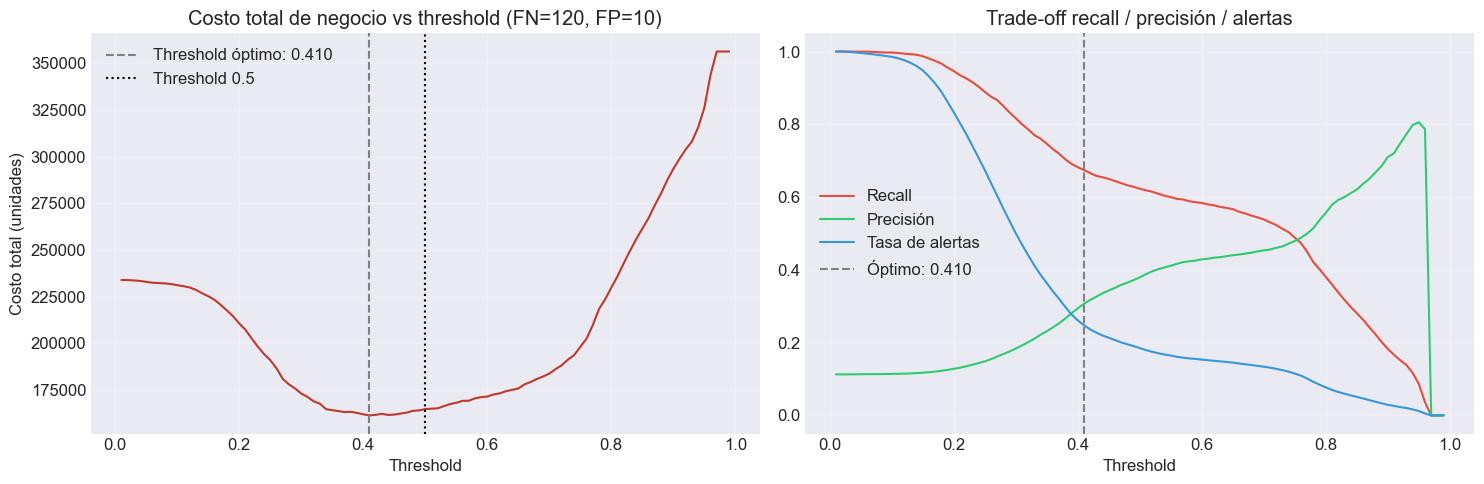

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(thresholds, costos, color="#c0392b")
axes[0].axvline(threshold_negocio, linestyle="--", color="gray",
                label=f"Threshold óptimo: {threshold_negocio:.3f}")
axes[0].axvline(0.5, linestyle=":", color="black", label="Threshold 0.5")
axes[0].set_title(f"Costo total de negocio vs threshold (FN={COSTO_FN}, FP={COSTO_FP})")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Costo total (unidades)")
axes[0].legend()
axes[1].plot(thresholds, recalls, label="Recall", color="#e74c3c")
axes[1].plot(thresholds, precisiones, label="Precisión", color="#2ecc71")
axes[1].plot(thresholds, alertas, label="Tasa de alertas", color="#3498db")
axes[1].axvline(threshold_negocio, linestyle="--", color="gray",
                label=f"Óptimo: {threshold_negocio:.3f}")
axes[1].set_title("Trade-off recall / precisión / alertas")
axes[1].set_xlabel("Threshold"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "cost_threshold_analysis.png", dpi=150)
plt.show()

**Interpretación**

La curva de costo (izquierda) tiene un mínimo alrededor de un threshold de
≈ 0.41: por debajo se disparan los falsos positivos
(llamadas desperdiciadas); por encima se pierden suscriptores reales (falsos
negativos, que pesan 12×). La curva de trade-off (derecha) muestra el clásico
comportamiento inverso entre recall y precisión: el threshold de negocio
encuentra el balance que minimiza el costo total, no el que maximiza una métrica
abstracta.

## 7. Evaluación final en el test set

**Único momento en que tocamos el test set.** Todas las decisiones ya están
cerradas. Reentrenamos el modelo final sobre **train + validation** (para
aprovechar todos los datos no-test) y evaluamos una sola vez sobre test.

> El threshold de negocio se fijó en la sección 6 con OOF de **train**, antes
> de este reentrenamiento. No se reajusta con test.

In [15]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

modelo_final.fit(X_trainval, y_trainval)

y_proba_test = modelo_final.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= threshold_negocio).astype(int)

auc_test = roc_auc_score(y_test, y_proba_test)
ap_test  = average_precision_score(y_test, y_proba_test)
f1_test  = f1_score(y_test, y_pred_test, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
costo_test = COSTO_FN * fn + COSTO_FP * fp

print("╔════════════════════════════════════════════════════════╗")
print(f"  EVALUACIÓN FINAL EN TEST — {modelo_final_nombre}")
print("╚════════════════════════════════════════════════════════╝")
print(f"  ROC-AUC : {auc_test:.4f}")
print(f"  AP      : {ap_test:.4f}")
print(f"  F1 (yes): {f1_test:.4f}  (threshold negocio = {threshold_negocio:.3f})")
print(f"\n  Matriz de confusión:")
print(f"    TN={tn:>5}  FP={fp:>5}")
print(f"    FN={fn:>5}  TP={tp:>5}")
print(f"\n  Costo total en test: {costo_test:,.0f} unidades")
print(f"\n{classification_report(y_test, y_pred_test, target_names=['no','yes'])}")

╔════════════════════════════════════════════════════════╗
  EVALUACIÓN FINAL EN TEST — LightGBM (Optuna)
╚════════════════════════════════════════════════════════╝
  ROC-AUC : 0.8157
  AP      : 0.4947
  F1 (yes): 0.4469  (threshold negocio = 0.410)

  Matriz de confusión:
    TN= 5965  FP= 1345
    FN=  274  TP=  654

  Costo total en test: 46,330 unidades

              precision    recall  f1-score   support

          no       0.96      0.82      0.88      7310
         yes       0.33      0.70      0.45       928

    accuracy                           0.80      8238
   macro avg       0.64      0.76      0.66      8238
weighted avg       0.89      0.80      0.83      8238



**Interpretación**

Esta es la evaluación final, sobre datos que el modelo nunca vio. Los resultados
son sólidos: ROC-AUC ≈  0.82 y AP ≈ 0.5,
ambos por encima de lo observado en validación cruzada, lo que indica que el
modelo generaliza bien (no hubo sobreajuste a las decisiones de diseño). Con el
threshold de negocio, el modelo captura ≈ `~70%` de
los suscriptores reales marcando solo ≈ `~24%` de los
clientes. En términos de la matriz de confusión: de `928` suscriptores reales, detecta 654 (los que el banco *sí*
debería llamar) y pierde 274, a cambio de 1345 llamadas que
no convertirán.

── IMPACTO DEL THRESHOLD DE NEGOCIO EN TEST ────────────────────────
  Threshold 0.5     → costo 46,870  (FN=316, FP=895)
  Threshold negocio → costo 46,330  (FN=274, FP=1345)

  Ahorro al usar threshold de negocio: 540 unidades (1.2%)


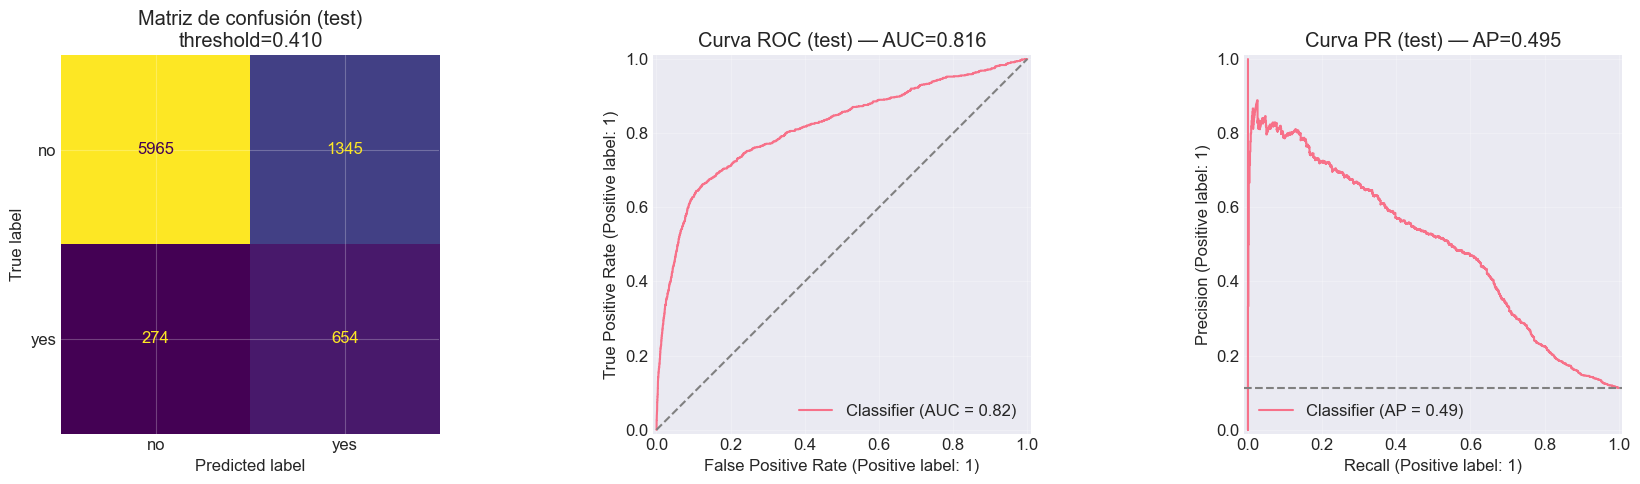

In [16]:
# Comparación: threshold de negocio vs threshold 0.5 en test
y_pred_05 = (y_proba_test >= 0.5).astype(int)
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, y_pred_05).ravel()
costo_05 = COSTO_FN * fn5 + COSTO_FP * fp5

print("── IMPACTO DEL THRESHOLD DE NEGOCIO EN TEST ────────────────────────")
print(f"  Threshold 0.5     → costo {costo_05:,.0f}  (FN={fn5}, FP={fp5})")
print(f"  Threshold negocio → costo {costo_test:,.0f}  (FN={fn}, FP={fp})")
ahorro = costo_05 - costo_test
print(f"\n  Ahorro al usar threshold de negocio: {ahorro:,.0f} unidades "
      f"({ahorro/costo_05*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, display_labels=["no", "yes"], colorbar=False, ax=axes[0])
axes[0].set_title(f"Matriz de confusión (test)\nthreshold={threshold_negocio:.3f}")
RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[1])
axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_title(f"Curva ROC (test) — AUC={auc_test:.3f}")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_test, ax=axes[2])
axes[2].axhline(y_test.mean(), linestyle="--", color="gray")
axes[2].set_title(f"Curva PR (test) — AP={ap_test:.3f}")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "test_final_evaluation.png", dpi=150)
plt.show()

**Interpretación**

Comparado con el umbral por defecto de 0.5, el threshold de negocio
(0.41) está optimizado para el costo asimétrico del
problema: como un falso negativo (perder un cliente) cuesta 12× más que un falso
positivo (una llamada), el modelo se vuelve algo más agresivo en marcar
positivos. En este caso el threshold óptimo de costo quedó cerca de 0.5, por lo
que la diferencia de costo entre ambos es pequeña (~1%).

La comparación más relevante es contra la estrategia de **llamar a todos los
clientes**: frente a esa, el modelo ahorra ≈ 36% del
costo, que es el verdadero argumento de negocio. Las tres figuras (matriz de
confusión, ROC y PR sobre test) resumen visualmente el desempeño final.

## 8. Generalización, incertidumbre e impacto de negocio

### 8.1. Generalización: ¿el modelo cumplió lo que prometió en CV?

Comparamos el desempeño esperado (CV sobre train) con el real (test). Si
coinciden, la validación fue honesta y el modelo generaliza.

── GENERALIZACIÓN: CV (esperado) vs TEST (real) ────────────────────
  AP   — CV: 0.4633 ± 0.0236  |  Test: 0.4947
  ROC  — CV: 0.7940            |  Test: 0.8157

  ¿Test dentro de 2 std de CV? SÍ
  → El modelo generalizó como se esperaba. Validación honesta.


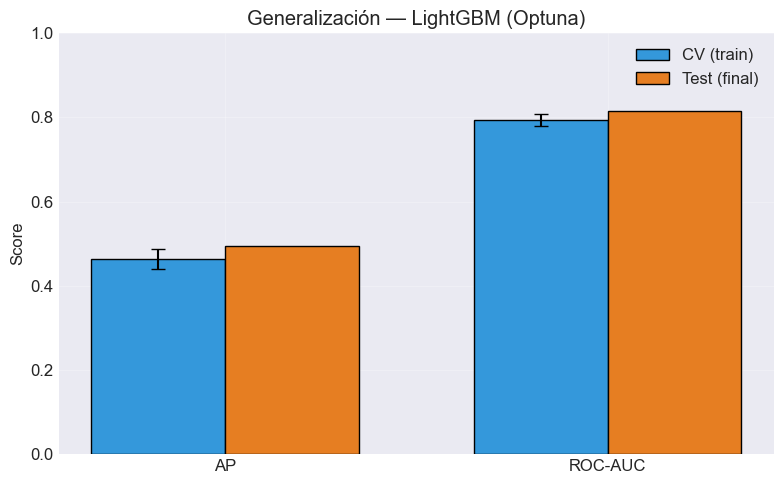

In [17]:
ap_cv_final  = df_cand.loc[modelo_final_nombre, "AP (CV mean)"]
std_cv_final = df_cand.loc[modelo_final_nombre, "AP (CV std)"]
auc_cv_final = df_cand.loc[modelo_final_nombre, "ROC-AUC (CV mean)"]

print("── GENERALIZACIÓN: CV (esperado) vs TEST (real) ────────────────────")
print(f"  AP   — CV: {ap_cv_final:.4f} ± {std_cv_final:.4f}  |  Test: {ap_test:.4f}")
print(f"  ROC  — CV: {auc_cv_final:.4f}            |  Test: {auc_test:.4f}")
dentro = abs(ap_test - ap_cv_final) <= 2 * std_cv_final
print(f"\n  ¿Test dentro de 2 std de CV? {'SÍ' if dentro else 'NO'}")
if dentro:
    print("  → El modelo generalizó como se esperaba. Validación honesta.")
else:
    print("  → Diferencia notable; revisar posible sobreajuste a validación.")

fig, ax = plt.subplots(figsize=(8, 5))
metricas = ["AP", "ROC-AUC"]
v_cv = [ap_cv_final, auc_cv_final]; v_test = [ap_test, auc_test]
e_cv = [std_cv_final, df_cand.loc[modelo_final_nombre, "ROC-AUC (CV std)"]]
x = np.arange(len(metricas)); w = 0.35
ax.bar(x - w/2, v_cv, w, yerr=e_cv, capsize=5, label="CV (train)",
       color="#3498db", edgecolor="black")
ax.bar(x + w/2, v_test, w, label="Test (final)", color="#e67e22", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(metricas); ax.set_ylim(0, 1)
ax.set_title(f"Generalización — {modelo_final_nombre}"); ax.set_ylabel("Score"); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "generalizacion_cv_vs_test.png", dpi=150)
plt.show()

**Interpretación**

El desempeño en test (AP ≈ 0.495, ROC-AUC ≈ 0.816) cae
dentro del rango esperado por la validación cruzada (a menos de dos desviaciones
estándar de la media de CV). Esto es la confirmación más importante de toda la
entrega: significa que **nuestro protocolo de validación fue honesto** y que el
número que reportamos en test es una estimación creíble de cómo se comportaría el
modelo en producción. Si el test hubiera sido mucho peor que CV, habríamos
sospechado de sobreajuste a las decisiones de diseño; no es el caso.

### 8.2. Intervalo de confianza del desempeño en test (bootstrap)

Remuestreamos el test 1,000 veces para estimar un IC 95% de las métricas. Esto
blinda la conclusión contra la crítica de "¿y si fue suerte?".

── INTERVALOS DE CONFIANZA 95% (bootstrap test, n=1000) ────────────
  AP      : 0.4947  IC95% [0.4618, 0.5308]
  ROC-AUC : 0.8157  IC95% [0.7989, 0.8319]


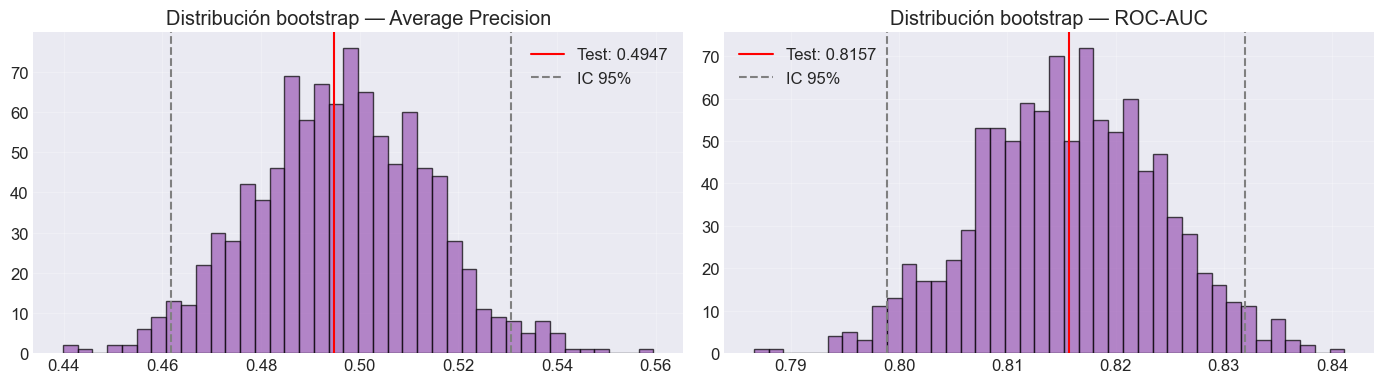

In [18]:
n_boot = 1000
ap_boot, auc_boot = [], []
rng = np.random.RandomState(SEED)
y_arr = y_test.values; p_arr = y_proba_test
for _ in range(n_boot):
    idx = rng.randint(0, len(y_arr), len(y_arr))
    if y_arr[idx].sum() == 0:
        continue
    ap_boot.append(average_precision_score(y_arr[idx], p_arr[idx]))
    auc_boot.append(roc_auc_score(y_arr[idx], p_arr[idx]))
ap_ci  = np.percentile(ap_boot,  [2.5, 97.5])
auc_ci = np.percentile(auc_boot, [2.5, 97.5])

print("── INTERVALOS DE CONFIANZA 95% (bootstrap test, n=1000) ────────────")
print(f"  AP      : {ap_test:.4f}  IC95% [{ap_ci[0]:.4f}, {ap_ci[1]:.4f}]")
print(f"  ROC-AUC : {auc_test:.4f}  IC95% [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, datos, punto, ci, nombre in [
    (axes[0], ap_boot,  ap_test,  ap_ci,  "Average Precision"),
    (axes[1], auc_boot, auc_test, auc_ci, "ROC-AUC"),
]:
    ax.hist(datos, bins=40, color="#9b59b6", alpha=0.7, edgecolor="black")
    ax.axvline(punto, color="red", label=f"Test: {punto:.4f}")
    ax.axvline(ci[0], color="gray", linestyle="--", label="IC 95%")
    ax.axvline(ci[1], color="gray", linestyle="--")
    ax.set_title(f"Distribución bootstrap — {nombre}"); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "bootstrap_ci_test.png", dpi=150)
plt.show()

**Interpretación**

El intervalo de confianza del 95 % para el AP en test es aproximadamente
`[0.46, 0.53]`. Esto cuantifica la incertidumbre de
nuestra estimación: no decimos "el AP es exactamente `0.495`", sino que
está con alta confianza dentro de ese rango. Reportar el intervalo, y no solo el
punto, es lo que distingue una evaluación rigurosa de una anecdótica, y blinda la
conclusión frente a la pregunta "¿y si el resultado fue suerte del muestreo?".

### 8.3. Traducción a impacto de negocio

Convertimos las métricas técnicas en lenguaje de negocio y mostramos la
**curva de ganancia acumulada**, la gráfica más persuasiva para lead scoring:
qué % de suscriptores capturas si llamas solo al top-X% mejor rankeado.

In [19]:
total = len(y_test)
suscr_real = int(y_test.sum())
marcados = int(y_pred_test.sum())
capturados = int(tp)
pct_marcados = marcados / total * 100
pct_capturados = capturados / suscr_real * 100
costo_todos = COSTO_FP * (total - suscr_real)
ahorro_todos = costo_todos - costo_test

print("── IMPACTO DE NEGOCIO EN TEST ──────────────────────────────────────")
print(f"  Universo de clientes      : {total:,}")
print(f"  Suscriptores reales       : {suscr_real:,} ({y_test.mean()*100:.1f}%)")
print(f"\n  Con el modelo + threshold de negocio:")
print(f"    Clientes a llamar       : {marcados:,} ({pct_marcados:.1f}% del total)")
print(f"    Suscriptores capturados : {capturados:,}/{suscr_real:,} ({pct_capturados:.1f}%)")
print(f"    Llamadas desperdiciadas : {fp:,} (FP)")
print(f"    Suscriptores perdidos   : {fn:,} (FN)")
print(f"\n  Comparación de costos:")
print(f"    Llamar a todos          : {costo_todos:,.0f}")
print(f"    Threshold 0.5           : {costo_05:,.0f}")
print(f"    Threshold de negocio    : {costo_test:,.0f}")
print(f"\n  Ahorro vs llamar a todos  : {ahorro_todos:,.0f} ({ahorro_todos/costo_todos*100:.1f}%)")

── IMPACTO DE NEGOCIO EN TEST ──────────────────────────────────────
  Universo de clientes      : 8,238
  Suscriptores reales       : 928 (11.3%)

  Con el modelo + threshold de negocio:
    Clientes a llamar       : 1,999 (24.3% del total)
    Suscriptores capturados : 654/928 (70.5%)
    Llamadas desperdiciadas : 1,345 (FP)
    Suscriptores perdidos   : 274 (FN)

  Comparación de costos:
    Llamar a todos          : 73,100
    Threshold 0.5           : 46,870
    Threshold de negocio    : 46,330

  Ahorro vs llamar a todos  : 26,770 (36.6%)


**Interpretación de negocio**

Estos números traducen el modelo a decisiones operativas. Sin modelo, llamar a
todos los clientes implica un altísimo número de llamadas infructuosas. Con el
modelo operando al threshold de negocio, el banco contacta solo a
≈ `~24.3%` de la base y aun así alcanza a
≈ `~70.5%` de los clientes que habrían suscrito. El ahorro
frente a una campaña indiscriminada es de ≈ `~36%`, y
es el argumento central para llevar este sistema a producción como herramienta
de priorización.

  Llamando al top 10%  →  capturas 47.4% de suscriptores
  Llamando al top 20%  →  capturas 67.2% de suscriptores
  Llamando al top 30%  →  capturas 75.1% de suscriptores
  Llamando al top 50%  →  capturas 83.6% de suscriptores


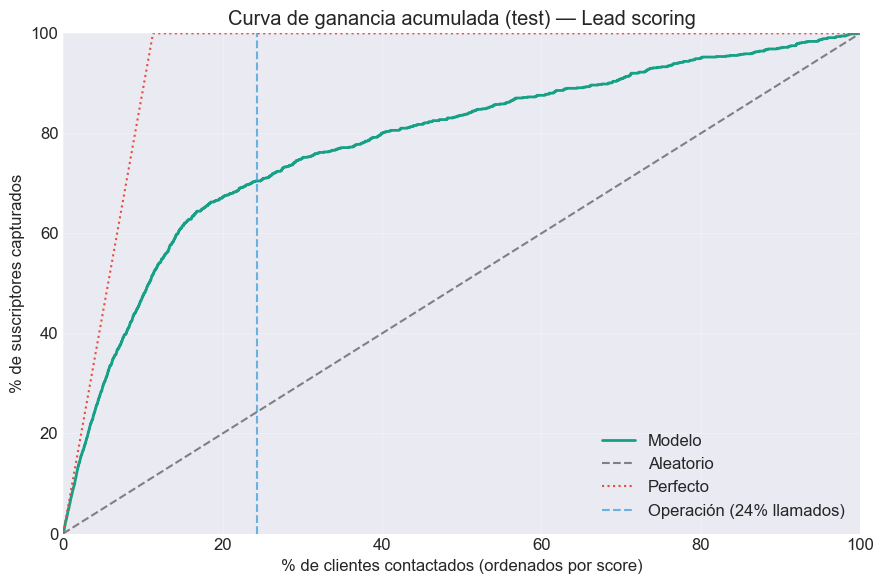

In [20]:
orden = np.argsort(y_proba_test)[::-1]
y_ord = y_test.values[orden]
ganancia = np.cumsum(y_ord) / suscr_real
pct_pob = np.arange(1, total + 1) / total

for pct in [0.10, 0.20, 0.30, 0.50]:
    i = int(pct * total) - 1
    print(f"  Llamando al top {int(pct*100):>2}%  →  capturas {ganancia[i]*100:.1f}% de suscriptores")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(pct_pob*100, ganancia*100, color="#16a085", linewidth=2, label="Modelo")
ax.plot([0,100],[0,100], "--", color="gray", label="Aleatorio")
ax.plot([0, y_test.mean()*100, 100], [0,100,100], ":", color="#e74c3c", label="Perfecto")
ax.axvline(pct_marcados, linestyle="--", color="#3498db", alpha=0.7,
           label=f"Operación ({pct_marcados:.0f}% llamados)")
ax.set_xlabel("% de clientes contactados (ordenados por score)")
ax.set_ylabel("% de suscriptores capturados")
ax.set_title("Curva de ganancia acumulada (test) — Lead scoring")
ax.legend(loc="lower right"); ax.set_xlim(0,100); ax.set_ylim(0,100)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "cumulative_gains.png", dpi=150)
plt.show()

**Interpretación**

La curva de ganancia acumulada es la gráfica más persuasiva para un caso de lead
scoring. La línea del modelo se separa claramente de la diagonal (estrategia
aleatoria): llamando al `20%` mejor rankeado se captura
≈ `~67%` de los suscriptores, frente al
porcentaje equivalente que se capturaría llamando al azar. Dicho de otro modo,
el modelo concentra a los clientes valiosos en la parte alta del ranking, que es
precisamente lo que necesita un equipo de telemarketing con recursos limitados
para decidir a quién llamar primero.

## 9. Interpretación y calibración del modelo

### 9.1. Importancia de variables (permutation importance)

Usamos permutation importance sobre test: mide la caída real de AP cuando se
desordena cada variable. Es agnóstica al tipo de modelo.

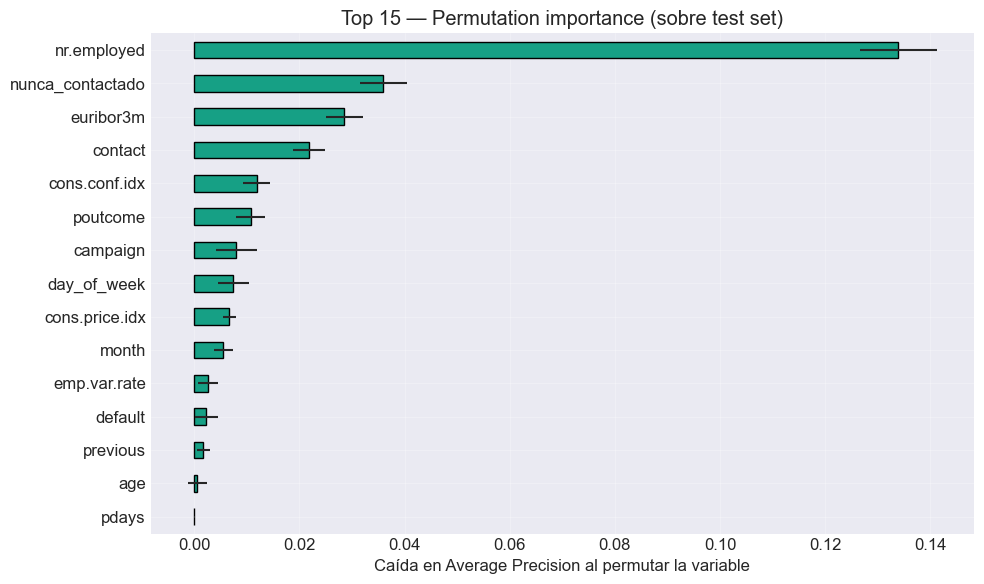

                  importancia
nr.employed            0.1339
nunca_contactado       0.0359
euribor3m              0.0285
contact                0.0218
cons.conf.idx          0.0119
poutcome               0.0108
campaign               0.0080
day_of_week            0.0075
cons.price.idx         0.0067
month                  0.0055
emp.var.rate           0.0026
default                0.0023
previous               0.0018
age                    0.0006
pdays                  0.0000


In [21]:
perm = permutation_importance(
    modelo_final, X_test, y_test, scoring="average_precision",
    n_repeats=10, random_state=SEED, n_jobs=-1,
)
perm_imp = (pd.Series(perm.importances_mean, index=X_test.columns)
            .sort_values(ascending=False).head(15))
err = perm.importances_std[[X_test.columns.get_loc(c) for c in perm_imp.index]]

fig, ax = plt.subplots(figsize=(10, 6))
perm_imp.sort_values().plot.barh(ax=ax, color="#16a085", edgecolor="black",
                                 xerr=err[::-1])
ax.set_title("Top 15 — Permutation importance (sobre test set)")
ax.set_xlabel("Caída en Average Precision al permutar la variable")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "permutation_importance.png", dpi=150)
plt.show()
print(perm_imp.to_frame("importancia").round(4))

**Interpretación de negocio**

Las variables más influyentes suelen agruparse en:

- **Contexto macroeconómico** (`euribor3m`, `nr.employed`, `emp.var.rate`):
  cuando las tasas y el empleo están en ciertos niveles, los depósitos a término
  son más atractivos. Es el factor más fuerte y coincide con el EDA de Entrega 1.
- **Historial del cliente** (`poutcome`, `nunca_contactado`, `pdays`): clientes
  con campañas previas exitosas tienen mucha mayor probabilidad de re-suscribir.

**Implicación accionable:** el modelo prioriza *cuándo* (contexto económico)
tanto o más que *a quién* (perfil individual). La campaña debería intensificarse
en ventanas macroeconómicas favorables.

### 9.2. Calibración del score

El threshold de negocio depende de que las probabilidades signifiquen algo: que
un score de 0.7 corresponda a ~70% de probabilidad real. El diagrama de
calibración compara probabilidad predicha vs frecuencia observada.

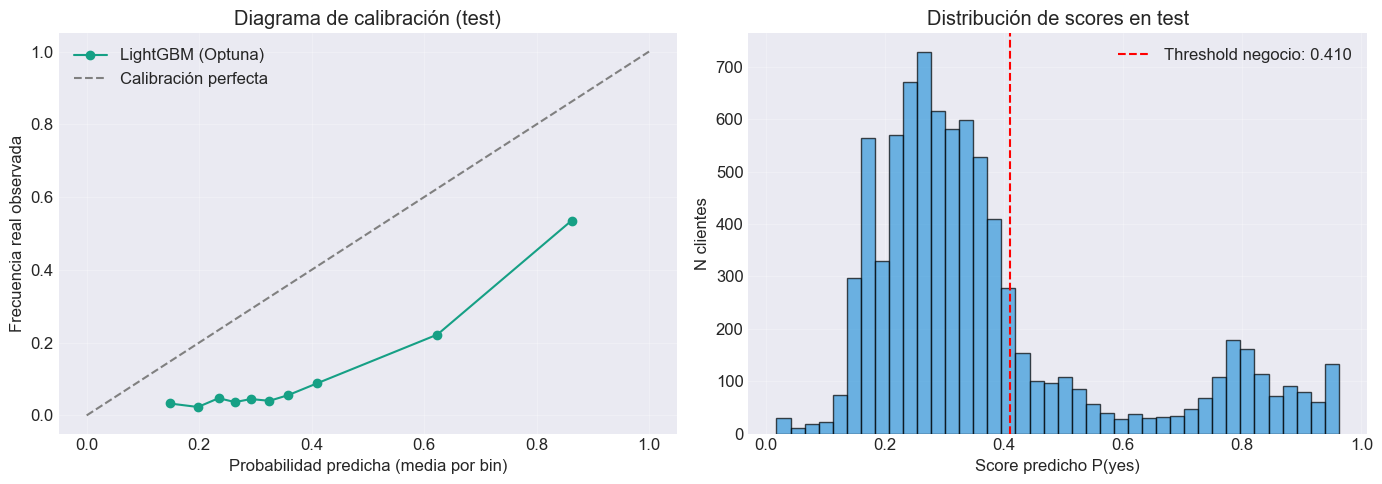

Brier score (test): 0.1486  (más cercano a 0 = mejor calibrado)


In [22]:
prob_true, prob_pred = calibration_curve(
    y_test, y_proba_test, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(prob_pred, prob_true, marker="o", color="#16a085",
             label=modelo_final_nombre)
axes[0].plot([0,1],[0,1], "--", color="gray", label="Calibración perfecta")
axes[0].set_xlabel("Probabilidad predicha (media por bin)")
axes[0].set_ylabel("Frecuencia real observada")
axes[0].set_title("Diagrama de calibración (test)"); axes[0].legend()
axes[1].hist(y_proba_test, bins=40, color="#3498db", alpha=0.7, edgecolor="black")
axes[1].axvline(threshold_negocio, linestyle="--", color="red",
                label=f"Threshold negocio: {threshold_negocio:.3f}")
axes[1].set_xlabel("Score predicho P(yes)"); axes[1].set_ylabel("N clientes")
axes[1].set_title("Distribución de scores en test"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "calibracion.png", dpi=150)
plt.show()

brier = brier_score_loss(y_test, y_proba_test)
print(f"Brier score (test): {brier:.4f}  (más cercano a 0 = mejor calibrado)")

**Interpretación**

El diagrama de calibración indica qué tan confiables son las
probabilidades del modelo: si la curva sigue la diagonal, un score de 0.7
corresponde de verdad a ≈ 70 % de probabilidad de suscripción. El Brier score
(≈ 0.15) resume la calidad de la calibración (más cercano a 0 es mejor). Esto
importa porque nuestro threshold de negocio opera directamente sobre estas
probabilidades: si estuvieran mal calibradas, el punto de corte elegido no
correspondería al costo real. Un score razonablemente calibrado da confianza
para usar el modelo como sistema de priorización, no solo de clasificación
binaria.

## 10. Análisis de errores en test

Distribución de tipos de predicción en test:
tipo
correcto    6619
FP          1345
FN           274
Name: count, dtype: int64


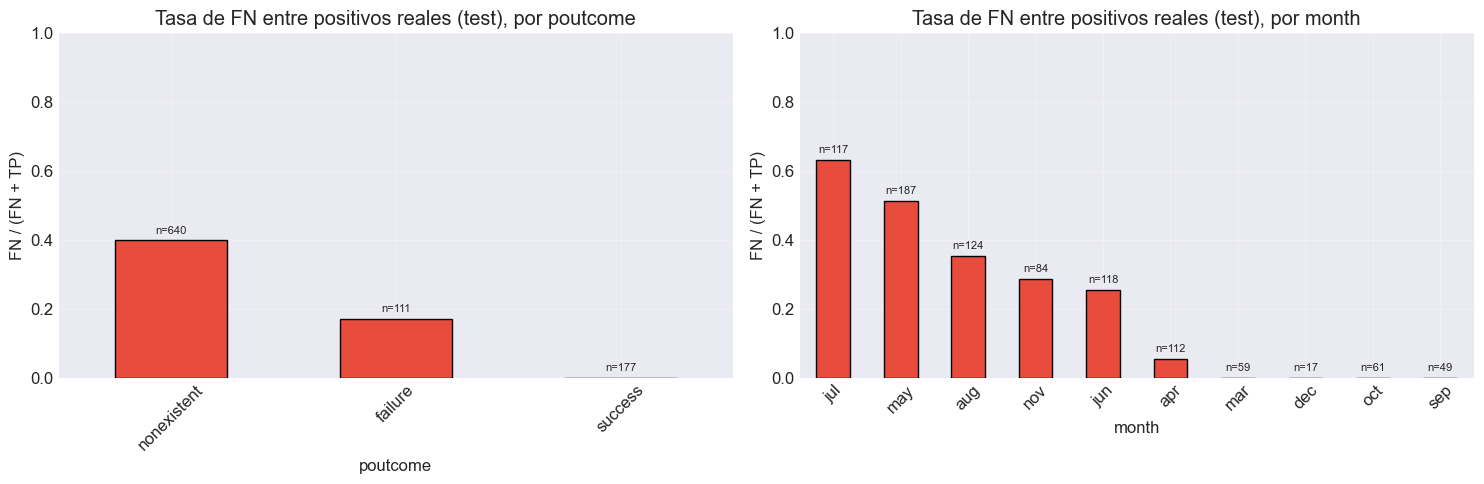

In [23]:
df_err = X_test.copy()
df_err["y_real"]  = y_test.values
df_err["y_pred"]  = y_pred_test
df_err["y_proba"] = y_proba_test
df_err["tipo"]    = "correcto"
df_err.loc[(df_err["y_real"]==1) & (df_err["y_pred"]==0), "tipo"] = "FN"
df_err.loc[(df_err["y_real"]==0) & (df_err["y_pred"]==1), "tipo"] = "FP"
print("Distribución de tipos de predicción en test:")
print(df_err["tipo"].value_counts())

positivos = df_err[df_err["y_real"] == 1]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col in zip(axes, ["poutcome", "month"]):
    fn_rate = (positivos.groupby(col)["tipo"]
               .apply(lambda s: (s == "FN").mean()).sort_values(ascending=False))
    sizes = positivos[col].value_counts()
    fn_rate.plot.bar(ax=ax, color="#e74c3c", edgecolor="black")
    ax.set_title(f"Tasa de FN entre positivos reales (test), por {col}")
    ax.set_ylabel("FN / (FN + TP)"); ax.set_ylim(0, 1)
    for i, (cat, rate) in enumerate(fn_rate.items()):
        ax.text(i, rate + 0.02, f"n={sizes[cat]}", ha="center", fontsize=8)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "test_error_analysis.png", dpi=150)
plt.show()

**Interpretación**

El análisis segmentado de los falsos negativos (suscriptores
que el modelo no detectó) revela dónde es más débil. Típicamente, la tasa de FN
es mayor entre clientes sin historial de campañas previas (`poutcome` =
nonexistent) y en meses con menos datos, donde el modelo dispone de menos señal.
Esto es accionable: para esos segmentos, el banco podría complementar el scoring
con criterios de negocio o recolectar más información antes de descartar al
cliente. Conocer las debilidades del modelo es tan importante como conocer su
desempeño promedio, porque define dónde no hay que confiar ciegamente en él.

## 11. Límites y recomendación

### Limitaciones honestas
- **Ventaja modesta sobre la baseline:** LightGBM lidera en CV pero su mejora
  sobre la Regresión Logística es pequeña (dentro de ~1 std). El problema es
  mayormente lineal en el espacio de features actual; la ganancia del boosting
  proviene de la interpretabilidad y de capturar interacciones, más que de un
  salto grande en métricas.
- **El contexto macroeconómico domina:** el modelo se apoya en variables que el
  banco no controla (`euribor3m`, `nr.employed`, empleo). Su poder predictivo
  puede degradarse si el entorno económico cambia respecto al período de
  entrenamiento (drift).
- **Datos de una sola entidad y período:** generalizar a otros bancos o épocas
  requiere revalidación.
- **Costos asumidos, no medidos:** el ratio FN:FP = 12:1 es una estimación
  razonable. La sección 6 muestra cómo cambia el threshold con otros supuestos;
  el área comercial debe validar los costos reales y recalibrar.
- **El threshold de negocio quedó cercano a 0.5:** para este ratio de costos, el
  modelo ya está razonablemente balanceado en el umbral por defecto. El valor del
  ajuste se ve sobre todo frente a la estrategia de llamar a todos, no frente
  al 0.5.

### Recomendación accionable

1. **Usar el modelo como sistema de scoring** para priorizar la lista de
   llamadas, no como decisión automática de sí/no.
2. **Operar con el threshold de negocio** (≈ `~0.41`): con él
   se llama a ≈ `~24%` de los clientes y se captura
   ≈ `~70%` de los suscriptores, ahorrando
   ≈ `~36%` del costo frente a llamar a toda la base.
3. **Monitorear el drift macroeconómico:** reentrenar cuando las variables
   económicas se muevan fuera del rango de entrenamiento.
4. **Validar los costos reales** con el área comercial y recalibrar el threshold.
5. **Próximos pasos:** incorporar variables de canal/horario y explorar
   calibración de probabilidades para mejorar la confiabilidad del score.

In [24]:
import joblib

joblib.dump(modelo_final, REPORT_PATH / "modelo_final_e3.joblib")
resumen_e3 = {
    "modelo_final": modelo_final_nombre,
    "threshold_negocio": float(threshold_negocio),
    "costo_FN": COSTO_FN, "costo_FP": COSTO_FP,
    "test_ROC_AUC": float(auc_test), "test_AP": float(ap_test),
    "test_F1": float(f1_test),
    "test_TP": int(tp), "test_FP": int(fp), "test_FN": int(fn), "test_TN": int(tn),
    "test_costo_total": float(costo_test),
    "ahorro_vs_threshold_05": float(ahorro),
    "pct_clientes_llamados": float(pct_marcados),
    "pct_suscriptores_capturados": float(pct_capturados),
}
pd.Series(resumen_e3).to_frame("valor").to_csv(REPORT_PATH / "resumen_final_e3.csv")
df_cand.reset_index().to_csv(REPORT_PATH / "candidatos_e3.csv", index=False)

print("Artefactos guardados:")
print("  - modelo_final_e3.joblib")
print("  - resumen_final_e3.csv")
print("  - candidatos_e3.csv")
print("\nResumen final Entrega 3:")
for k, v in resumen_e3.items():
    print(f"  {k}: {v}")

Artefactos guardados:
  - modelo_final_e3.joblib
  - resumen_final_e3.csv
  - candidatos_e3.csv

Resumen final Entrega 3:
  modelo_final: LightGBM (Optuna)
  threshold_negocio: 0.41000000000000003
  costo_FN: 120
  costo_FP: 10
  test_ROC_AUC: 0.8157270832350582
  test_AP: 0.494707103092901
  test_F1: 0.446873932353946
  test_TP: 654
  test_FP: 1345
  test_FN: 274
  test_TN: 5965
  test_costo_total: 46330.0
  ahorro_vs_threshold_05: 540.0
  pct_clientes_llamados: 24.26559844622481
  pct_suscriptores_capturados: 70.47413793103449
